# Bitcoin Causal Performance Modeling
## Project 027 - Ginger AM Partnership

**Objective:** Build a causal model identifying key drivers of Bitcoin performance across different time horizons (1d, 7d, 30d, 90d).

**Meeting Goals addressed in this notebook:**
1. **Horizon Analysis:** Identify which factors (Sentiment vs OnChain vs Macro) dominate at different timeframes.
2. **Data Consistency:** Rigorous cleaning and merging of daily/monthly datasets.
3. **Feature Selection:** Using Clustered MDA (Mean Decrease Accuracy) to handle multicollinearity.
4. **Stationarity:** Ensuring all data is stationary to avoid spurious regression results.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, confusion_matrix, classification_report
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

# Define base paths
BASE_DIR = Path('../data')
PROCESSED_DIR = BASE_DIR / 'processed'
RAW_DIR = BASE_DIR / 'raw'
OUTPUT_DIR = BASE_DIR / 'outputs'

print(f"Base directory: {BASE_DIR.resolve()}")

Base directory: /Users/alvaro/Documents/GitHub/Projet-PI2-BTC/data


## 1. Data Loading and Merging

We need to merge datasets with different frequencies:
- **On-Chain & Sentiment:** Daily frequency.
- **Macro (Inflation, Rates, GDP):** Often Monthly or Quarterly frequency.

**Strategy:** We will load all datasets, index them by Date, and use forward-filling (`ffill`) for macro data. This simulates the information available to an investor on any given day (i.e., on Jan 15th, the latest Inflation rate known is likely from Dec).

In [37]:
# Define file paths using pathlib
files = {
    'onchain': PROCESSED_DIR / 'onchain_data_finalized.csv',
    'sentiment': PROCESSED_DIR / 'sentiment_dataset.csv',
    # Macro data from Excel file (read specific sheets)
    'macro_excel': RAW_DIR / 'indicatorsMY_v01.xlsx'
}

def load_and_clean(filepath, prefix='', sheet_name=None):
    """Load and clean a CSV or Excel file with automatic date detection."""
    try:
        filepath = Path(filepath)
        
        # Check if file exists
        if not filepath.exists():
            print(f"Warning: File not found: {filepath}")
            return None
        
        # Read file based on extension
        if filepath.suffix == '.xlsx':
            if sheet_name is None:
                print(f"Warning: Sheet name required for Excel file: {filepath}")
                return None
            df = pd.read_excel(filepath, sheet_name=sheet_name)
        else:
            df = pd.read_csv(filepath)
        
        # Convert all column names to strings (Excel can have datetime columns as headers)
        df.columns = [str(c) for c in df.columns]
        
        # Auto-detect date column (case-insensitive)
        date_cols = [c for c in df.columns if 'date' in c.lower()]
        if not date_cols:
            # Check for 'DATES' specifically (common in macro files)
            if 'DATES' in df.columns:
                date_cols = ['DATES']
            else:
                # For macro Excel files, the first column is often the date
                # Check if first column contains date-like values
                first_col = df.columns[0]
                try:
                    test_dates = pd.to_datetime(df[first_col].head(10), errors='coerce')
                    if test_dates.notna().sum() >= 5:  # At least 5 valid dates
                        date_cols = [first_col]
                        print(f"  Using first column '{first_col}' as date column")
                except:
                    pass
                
                if not date_cols:
                    print(f"Warning: No date column found in {filepath} (sheet: {sheet_name}). Skipping.")
                    return None
        
        col_name = date_cols[0]
        df[col_name] = pd.to_datetime(df[col_name], errors='coerce')
        
        # Drop rows where date parsing failed
        df = df.dropna(subset=[col_name])
        df = df.set_index(col_name).sort_index()
        df.index.name = 'date'
        
        # Normalize timezone: convert to tz-naive (remove timezone info)
        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)
        
        # Drop completely empty columns
        df = df.dropna(how='all', axis=1)
        
        # Convert numeric columns and handle object types
        for col in df.columns:
            if df[col].dtype == 'object':
                df[col] = pd.to_numeric(df[col], errors='coerce')
        
        # Prefix columns to avoid collisions
        if prefix:
            df.columns = [f"{prefix}_{c}" for c in df.columns]
            
        return df
    except Exception as e:
        print(f"Error loading {filepath} (sheet: {sheet_name}): {e}")
        import traceback
        traceback.print_exc()
        return None


def load_transposed_macro_sheet(filepath, sheet_name, prefix='', indicator_filter=None):
    """
    Load macro data from Excel sheets where dates are column headers (transposed format).
    
    Parameters:
    -----------
    filepath : Path - Path to Excel file
    sheet_name : str - Sheet name to load
    prefix : str - Prefix for column names
    indicator_filter : list - If provided, only load these specific indicators
    """
    try:
        df = pd.read_excel(filepath, sheet_name=sheet_name)
        
        if len(df.columns) < 3:
            print(f"  Sheet {sheet_name} has too few columns")
            return None
        
        # Extract indicator names and field types
        indicator_col = df.columns[0]
        field_col = df.columns[1]
        
        # Get date columns (all columns after the first two)
        date_cols = df.columns[2:]
        
        # Convert date column headers to datetime
        dates = pd.to_datetime(date_cols, errors='coerce')
        
        # Filter out invalid dates
        valid_mask = dates.notna()
        dates = dates[valid_mask]
        date_cols = [c for c, v in zip(date_cols, valid_mask) if v]
        
        if len(dates) == 0:
            print(f"  No valid date columns found in {sheet_name}")
            return None
        
        # We'll focus on 'px_last' values (closing prices) as the main metric
        # Create a pivot: each indicator becomes a column, dates become the index
        result_data = {}
        
        for idx, row in df.iterrows():
            indicator_name = str(row[indicator_col]).strip()
            field_type = str(row[field_col]).strip()
            
            # Only use 'px_last' (last/closing price) to avoid duplicates
            if field_type != 'px_last':
                continue
            
            # If filter is provided, only include specified indicators
            if indicator_filter is not None:
                if indicator_name not in indicator_filter:
                    continue
            
            # Clean indicator name for use as column name
            clean_name = indicator_name.replace(' ', '_').replace('/', '_').replace('.', '')
            
            # Extract values for this indicator
            values = row[date_cols].values
            result_data[clean_name] = values
        
        if not result_data:
            print(f"  No matching indicators found in {sheet_name}")
            return None
        
        # Create DataFrame with dates as index
        result_df = pd.DataFrame(result_data, index=dates)
        result_df.index.name = 'date'
        result_df = result_df.sort_index()
        
        # Convert to numeric and drop all-NaN columns
        for col in result_df.columns:
            result_df[col] = pd.to_numeric(result_df[col], errors='coerce')
        result_df = result_df.dropna(how='all', axis=1)
        
        # Prefix columns
        if prefix:
            result_df.columns = [f"{prefix}_{c}" for c in result_df.columns]
        
        return result_df
        
    except Exception as e:
        print(f"Error loading transposed sheet {sheet_name}: {e}")
        import traceback
        traceback.print_exc()
        return None


# =============================================================================
# MACRO INDICATOR SELECTION FOR CAUSAL ANALYSIS
# =============================================================================
# Based on ChatGPT recommendations and causal analysis best practices

# Define which indicators to extract from each sheet
MACRO_INDICATORS = {
    'Market_Indicators': {
        'prefix': 'MACRO_MKT',
        'indicators': [
            'VIX Index',           # ✅ Core: Equity volatility (fear gauge)
            'MOVE Index',          # ✅ Core: Bond market volatility
            'JPMVXYGL Index',      # ⚠️ Optional: Global FX volatility
            # Excluded: CVIX Index (currency vol - redundant with JPMVXYGL)
            # Excluded: MARA, RIOT, etc. (crypto mining stocks - not causal drivers)
        ],
        'description': 'Volatility & Risk Sentiment'
    },
    'Inflation': {
        'prefix': 'MACRO_CPI',
        'indicators': [
            'CPI XYOY Index',      # ✅ Core: US CPI YoY
            'CPEXEMUY Index',      # ✅ Core: US Core CPI (ex food & energy)
            'JCPNEFEY Index',      # Japan CPI
            'CNCPCRY Index',       # China CPI
        ],
        'description': 'Inflation Metrics'
    },
    'Central_Banks_Policy_Rates': {
        'prefix': 'MACRO_RATE',
        'indicators': [
            'FDTR Index',          # ✅ Core: Fed Funds Target Rate
            'EURR002W Index',      # ⚠️ Optional: ECB Rate
            'BOJDPBAL Index',      # Bank of Japan
            'CHRRDEPC Index',      # China Rate
        ],
        'description': 'Central Bank Policy Rates'
    },
    'Money_Supply': {
        'prefix': 'MACRO_M2',
        'indicators': [
            'M2 Index',            # ✅ Core: US M2 Money Supply (liquidity)
            'ECMAM2 Index',        # Eurozone M2
            'JMNSM2SA Index',      # Japan M2
            'CNMSM2 Index',        # China M2
        ],
        'description': 'Money Supply / Liquidity'
    },
    '3M_Gov__Bonds': {
        'prefix': 'MACRO_3M',
        'indicators': [
            'USGG3M Index',        # ✅ Core: US 3-month Treasury yield
            'GETB1 Index',         # Germany 3M
            'GJGB3M Index',        # Japan 3M
        ],
        'description': 'Short-term Government Bonds'
    },
    'Yield_Curve': {
        'prefix': 'MACRO_YC',
        'indicators': [
            'USYC2Y10 Index',      # ✅ Core: US 2Y-10Y Yield Curve (recession indicator)
            'DEYC2Y10 Index',      # Germany Yield Curve
            'JPYC2Y10 Index',      # Japan Yield Curve
        ],
        'description': 'Yield Curve Spreads (Recession Indicators)'
    },
    'Foreign_Exchange': {
        'prefix': 'MACRO_FX',
        'indicators': [
            'EURUSD Curncy',       # EUR/USD exchange rate
            'JPYUSD Curncy',       # JPY/USD (risk-off indicator)
            'CNH Curncy',          # CNH/USD (China offshore yuan)
        ],
        'description': 'Foreign Exchange Rates'
    },
}

# Summary of indicator categories
print("=" * 60)
print("MACRO INDICATOR SELECTION FOR CAUSAL ANALYSIS")
print("=" * 60)
print("\n✅ Core Variables (High Causal Value):")
print("   - FDTR Index: Fed Funds Rate")
print("   - CPI XYOY Index: US CPI YoY")
print("   - CPEXEMUY Index: US Core CPI")
print("   - VIX Index: Equity Volatility")
print("   - MOVE Index: Bond Volatility")
print("   - M2 Index: US Money Supply")
print("   - USYC2Y10 Index: US Yield Curve")
print("   - USGG3M Index: US 3M Treasury")
print("\n⚠️  Secondary Variables:")
print("   - EURR002W Index: ECB Rate")
print("   - JPMVXYGL Index: Global FX Volatility")
print("   - Regional CPI/Rates (Japan, China, EU)")
print("\n❌ Excluded:")
print("   - CVIX Index: Redundant with FX vol")
print("   - Crypto mining stocks: Not causal drivers")
print("=" * 60)

# Load core datasets
df_onchain = load_and_clean(files['onchain'], prefix='ONCHAIN')
df_sentiment = load_and_clean(files['sentiment'], prefix='SENT')

# Load macro data from Excel sheets with specific indicator selection
macro_dfs = []
if files['macro_excel'].exists():
    xl = pd.ExcelFile(files['macro_excel'])
    print(f"\nAvailable Excel sheets: {xl.sheet_names}")
    
    for sheet_name, config in MACRO_INDICATORS.items():
        if sheet_name in xl.sheet_names:
            print(f"\n📊 Loading {sheet_name} ({config['description']})...")
            df_macro = load_transposed_macro_sheet(
                files['macro_excel'], 
                sheet_name, 
                prefix=config['prefix'],
                indicator_filter=config['indicators']
            )
            if df_macro is not None and not df_macro.empty:
                macro_dfs.append(df_macro)
                print(f"   ✓ Loaded: {list(df_macro.columns)}")
            else:
                print(f"   ✗ No data loaded")
else:
    print(f"Warning: Macro Excel file not found at {files['macro_excel']}")

# Display loaded data summary
print(f"\n{'='*60}")
print("DATA LOADING SUMMARY")
print(f"{'='*60}")
print(f"OnChain: {df_onchain.shape if df_onchain is not None else 'Not loaded'}")
print(f"Sentiment: {df_sentiment.shape if df_sentiment is not None else 'Not loaded'}")
print(f"Macro DataFrames loaded: {len(macro_dfs)}")

total_macro_cols = sum(len(df.columns) for df in macro_dfs)
print(f"Total Macro indicators: {total_macro_cols}")

for i, df_m in enumerate(macro_dfs):
    print(f"  DF {i+1}: {df_m.shape}, range: {df_m.index.min().date()} to {df_m.index.max().date()}")

# ============================================================
# CONFIGURATION: Extend Date Range for More Training Data
# ============================================================
START_DATE = "2018-03-01"  # Match teammate's analysis - sentiment starts 2018-02
TRAIN_END_DATE = "2023-12-31"  # Clear train/test split date

# Merge Strategy: Start with OnChain (Daily) as the main timeline
df_master = df_onchain.copy() if df_onchain is not None else pd.DataFrame()

if df_sentiment is not None:
    df_master = df_master.join(df_sentiment, how='left')

# Merge Macro data
for df_macro in macro_dfs:
    if df_macro is not None and not df_macro.empty:
        df_master = df_master.join(df_macro, how='left')

# Forward fill all data (simulates knowing last available data)
# This is the KEY CHANGE: fill forward instead of dropping NaN rows
df_master = df_master.ffill()

# Apply start date filter to get more historical data
df_master = df_master[df_master.index >= pd.to_datetime(START_DATE)]

# Only drop rows with too many missing values (>50% missing after ffill)
min_valid_cols = int(len(df_master.columns) * 0.5)
initial_len = len(df_master)
df_master = df_master.dropna(thresh=min_valid_cols)

# Final backward fill for any remaining NaNs at the start
df_master = df_master.bfill()
dropped = initial_len - len(df_master)

print(f"\n{'='*60}")
print("FINAL MERGED DATASET")
print(f"{'='*60}")
print(f"Shape: {df_master.shape}")
print(f"Rows dropped (incomplete): {dropped}")
print(f"Date Range: {df_master.index.min().date()} to {df_master.index.max().date()}")
print(f"\nColumn categories:")
onchain_cols = [c for c in df_master.columns if c.startswith('ONCHAIN')]
sentiment_cols = [c for c in df_master.columns if c.startswith('SENT')]
macro_cols = [c for c in df_master.columns if c.startswith('MACRO')]
print(f"  - OnChain: {len(onchain_cols)}")
print(f"  - Sentiment: {len(sentiment_cols)}")
print(f"  - Macro: {len(macro_cols)}")

# Show all macro columns
if macro_cols:
    print(f"\n📈 Macro Features Included:")
    for col in sorted(macro_cols):
        print(f"    - {col}")

MACRO INDICATOR SELECTION FOR CAUSAL ANALYSIS

✅ Core Variables (High Causal Value):
   - FDTR Index: Fed Funds Rate
   - CPI XYOY Index: US CPI YoY
   - CPEXEMUY Index: US Core CPI
   - VIX Index: Equity Volatility
   - MOVE Index: Bond Volatility
   - M2 Index: US Money Supply
   - USYC2Y10 Index: US Yield Curve
   - USGG3M Index: US 3M Treasury

⚠️  Secondary Variables:
   - EURR002W Index: ECB Rate
   - JPMVXYGL Index: Global FX Volatility
   - Regional CPI/Rates (Japan, China, EU)

❌ Excluded:
   - CVIX Index: Redundant with FX vol
   - Crypto mining stocks: Not causal drivers

Available Excel sheets: ['Alternatives', 'Market_Indicators', 'Price_Level_BTC', 'Open_Interests_Futures', 'Money_Supply', 'Central_Banks_Balance_Sheets', 'Central_Banks_Policy_Rates', 'TED_Spreads', '3M_Gov__Bonds', 'Yield_Curve', 'Foreign_Exchange', 'Miscellaneous', 'Gross_Domestic_Products', 'Industrial_Production', 'Retail_Sales', 'Inflation', 'Economic_Surprises', 'Economic Policy Uncertainty', 'Semico

In [31]:
df_master.to_csv("test.csv")

## 2. Stationarity & Transformations

**Meeting Note:** "Make sure to understand what type of data is selected what type of data is dropped."

We must transform non-stationary data (random walks) into stationary data to perform valid feature selection.
- **Prices/Volumes:** Log-Returns or % Change.
- **Ratios (MVRV, Fear&Greed):** Often stationary, but need checking.
- **Macro (CPI, Rates):** First Differences (Change in Rate).

In [38]:
def check_stationarity(series, cutoff=0.05):
    """
    Check if a series is stationary using the Augmented Dickey-Fuller test.
    Returns True if stationary (p-value < cutoff).
    """
    try:
        # Clean the series
        s = series.replace([np.inf, -np.inf], np.nan).dropna()
        if len(s) < 20:
            return False  # Too short for reliable ADF test
        result = adfuller(s, autolag='AIC')
        return result[1] < cutoff
    except Exception:
        return False

df_stat = pd.DataFrame()
diff_map = {}
dropped_cols = []

# 1. Identify the BTC Price column (our target)
price_cols = [c for c in df_master.columns if 'price_usd' in c.lower()]
if not price_cols:
    raise ValueError("No price_usd column found! Check the onchain data.")
    
price_col = price_cols[0]
print(f"Target Price Column: {price_col}")

# Create log returns for BTC price
df_stat['BTC_Log_Ret'] = np.log(df_master[price_col] / df_master[price_col].shift(1))

# 2. Process all other columns
for col in df_master.columns:
    if col == price_col:
        continue
    
    # Skip non-numeric columns
    if not np.issubdtype(df_master[col].dtype, np.number):
        dropped_cols.append((col, 'Non-numeric'))
        continue
    
    # Skip columns with too many NaNs or constant values
    if df_master[col].isna().sum() > len(df_master) * 0.5:
        dropped_cols.append((col, 'Too many NaNs'))
        continue
    
    if df_master[col].std() == 0:
        dropped_cols.append((col, 'Constant'))
        continue
    
    series = df_master[col]
    
    # Try transformations in order of preference
    if check_stationarity(series):
        df_stat[col] = series
        diff_map[col] = 'Original'
    else:
        # Try differencing
        diff_series = series.diff()
        if check_stationarity(diff_series):
            df_stat[col] = diff_series
            diff_map[col] = 'Differenced'
        else:
            # Try percentage change (good for hash rate, volume, etc.)
            pct_series = series.pct_change()
            if check_stationarity(pct_series):
                df_stat[col] = pct_series
                diff_map[col] = 'Pct_Change'
            else:
                # Try log returns (for price-like data)
                if (series > 0).all():
                    log_ret = np.log(series / series.shift(1))
                    if check_stationarity(log_ret):
                        df_stat[col] = log_ret
                        diff_map[col] = 'Log_Return'
                    else:
                        dropped_cols.append((col, 'Non-stationary'))
                else:
                    dropped_cols.append((col, 'Non-stationary'))

# Clean up infinite values and NaNs
df_stat = df_stat.replace([np.inf, -np.inf], np.nan).dropna()

# Summary
print(f"\n--- Stationarity Summary ---")
print(f"Final Stationary Dataset Shape: {df_stat.shape}")
print(f"\nTransformations applied:")
transform_counts = pd.Series(diff_map.values()).value_counts()
for t, count in transform_counts.items():
    print(f"  - {t}: {count} features")

print(f"\nDropped features: {len(dropped_cols)}")
if dropped_cols[:5]:  # Show first 5
    for col, reason in dropped_cols[:5]:
        print(f"  - {col}: {reason}")
    if len(dropped_cols) > 5:
        print(f"  ... and {len(dropped_cols) - 5} more")

Target Price Column: ONCHAIN_price_usd

--- Stationarity Summary ---
Final Stationary Dataset Shape: (2876, 112)

Transformations applied:
  - Original: 57 features
  - Differenced: 54 features

Dropped features: 0


## 3. Horizon Analysis & Feature Selection

**Meeting Note:** "Different horizons top 10 factors capture different things short vs long term horizons."

We will loop through horizons `[1, 7, 30]` days. For each horizon:
1.  Create a target variable (Future Return over N days).
2.  Run Clustered MDA to find the top features.
3.  Store results to compare.

In [39]:
def clustered_mda(X, y, n_splits=5, correlation_threshold=0.7):
    """
    Clustered Mean Decrease Accuracy (MDA) for feature importance.
    Handles multicollinearity by clustering correlated features.
    
    Parameters:
    -----------
    X : DataFrame - Feature matrix
    y : Series - Target variable
    n_splits : int - Number of CV folds
    correlation_threshold : float - Correlation threshold for clustering (0-1)
                                   Higher = more clusters (less aggressive grouping)
    """
    # Remove constant columns
    X = X.loc[:, X.std() > 0]
    
    if X.empty:
        return pd.Series(dtype=float)
    
    n_features = X.shape[1]
    
    # 1. Compute correlation matrix and cluster features
    corr = X.corr(method='spearman').fillna(0)
    
    # Ensure the distance matrix is valid (between 0 and 1)
    dist_matrix = 1 - corr.abs()
    dist_matrix = np.clip(dist_matrix, 0, 1)
    np.fill_diagonal(dist_matrix.values, 0)
    
    try:
        # Convert to condensed form for hierarchical clustering
        condensed_dist = squareform(dist_matrix, checks=False)
        linkage_matrix = hierarchy.ward(condensed_dist)
        
        # Use correlation threshold to determine clusters
        # Distance threshold = 1 - correlation_threshold
        # For correlation_threshold=0.7, we cluster features with |corr| > 0.7
        distance_threshold = 1 - correlation_threshold
        
        # Scale the threshold to the linkage matrix scale
        # Ward linkage uses squared distances, so we need to adjust
        max_height = linkage_matrix[:, 2].max()
        scaled_threshold = distance_threshold * max_height * 0.5  # Adjusted scaling
        
        cluster_ids = hierarchy.fcluster(linkage_matrix, scaled_threshold, criterion='distance')
        
    except Exception as e:
        print(f"  Clustering failed, treating each feature independently: {e}")
        cluster_ids = np.arange(1, len(X.columns) + 1)
    
    # Map clusters to features
    cluster_map = {}
    for feat, clust in zip(X.columns, cluster_ids):
        cluster_map.setdefault(clust, []).append(feat)
    
    n_clusters = len(cluster_map)
    print(f"  Features: {n_features} → Clusters: {n_clusters}")
    
    # Sanity check: if we have too few clusters, fallback to individual features
    if n_clusters < min(5, n_features // 10):
        print(f"  ⚠️  Too few clusters ({n_clusters}), using individual feature importance instead")
        cluster_map = {i: [feat] for i, feat in enumerate(X.columns)}
        n_clusters = len(cluster_map)
    
    # 2. Cross-validation setup
    kf = KFold(n_splits=n_splits, shuffle=False)
    raw_scores = {c: [] for c in cluster_map.keys()}
    
    model = RandomForestRegressor(
        n_estimators=100, 
        max_depth=8, 
        min_samples_leaf=5,
        random_state=42, 
        n_jobs=-1
    )
    
    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        baseline = r2_score(y_test, model.predict(X_test))
        
        # Permute each cluster and measure importance
        for c_id, feats in cluster_map.items():
            X_test_perm = X_test.copy()
            # Shuffle cluster features together to preserve within-cluster correlation
            perm_idx = np.random.permutation(len(X_test_perm))
            X_test_perm[feats] = X_test_perm[feats].iloc[perm_idx].values
            
            perm_score = r2_score(y_test, model.predict(X_test_perm))
            raw_scores[c_id].append(baseline - perm_score)

    # 3. Aggregate importance scores
    final_imp = {}
    for c_id, scores in raw_scores.items():
        mean_score = np.mean(scores)
        # Assign full importance to each feature in cluster (not divided)
        # This way, if a cluster is important, all its features show that importance
        for f in cluster_map[c_id]:
            final_imp[f] = mean_score
    
    # Also get native RF feature importances for comparison
    model.fit(X, y)
    rf_importance = pd.Series(model.feature_importances_, index=X.columns)
    
    # Combine: use permutation importance, but weighted by RF importance within clusters
    result = pd.Series(final_imp)
    
    # Normalize to make scores more interpretable
    if result.max() > 0:
        result = result / result.max()
            
    return result.sort_values(ascending=False)


# Also add a simpler permutation importance as backup
def simple_permutation_importance(X, y, n_repeats=10):
    """
    Simple permutation importance without clustering.
    More reliable for smaller datasets.
    """
    from sklearn.inspection import permutation_importance
    
    model = RandomForestRegressor(
        n_estimators=100, 
        max_depth=8, 
        min_samples_leaf=5,
        random_state=42, 
        n_jobs=-1
    )
    
    # Time series split: use last 20% as test
    split = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model.fit(X_train, y_train)
    
    result = permutation_importance(model, X_test, y_test, n_repeats=n_repeats, random_state=42, n_jobs=-1)
    
    importance = pd.Series(result.importances_mean, index=X.columns)
    return importance.sort_values(ascending=False)


# Run horizon analysis
horizons = [1, 7, 30]
results = {}

print("=" * 60)
print("HORIZON ANALYSIS - Feature Importance")
print("=" * 60)

for h in horizons:
    print(f"\n{'='*60}")
    print(f"Analyzing {h}-Day Horizon")
    print(f"{'='*60}")
    
    # Create Target: Future Cumulative Return over h days
    # Sum of log returns = cumulative return
    target = df_stat['BTC_Log_Ret'].rolling(window=h).sum().shift(-h)
    
    # Align data (remove rows where target is NaN)
    valid_idx = target.dropna().index
    X_h = df_stat.loc[valid_idx].drop(columns=['BTC_Log_Ret'])
    y_h = target.loc[valid_idx]
    
    print(f"  Samples: {len(X_h)}, Features: {X_h.shape[1]}")
    print(f"  Target stats: mean={y_h.mean():.4f}, std={y_h.std():.4f}")
    
    # Run clustered MDA with adjusted threshold
    imps = clustered_mda(X_h, y_h, correlation_threshold=0.8)
    results[h] = imps
    
    # Show top features by category
    print(f"\n  📊 Top 10 Drivers for {h}-Day Horizon:")
    for i, (feat, score) in enumerate(imps.head(10).items(), 1):
        # Categorize the feature
        if feat.startswith('ONCHAIN'):
            cat = '🔗 OnChain'
        elif feat.startswith('SENT'):
            cat = '💬 Sentiment'
        elif feat.startswith('MACRO'):
            cat = '📈 Macro'
        else:
            cat = '❓ Other'
        print(f"    {i:2d}. [{cat}] {feat}: {score:.4f}")
    
    # Summary by category
    print(f"\n  Category Summary (avg importance of top 20):")
    top20 = imps.head(20)
    for prefix, name in [('ONCHAIN', 'OnChain'), ('SENT', 'Sentiment'), ('MACRO', 'Macro')]:
        cat_feats = [f for f in top20.index if f.startswith(prefix)]
        if cat_feats:
            avg_imp = top20[cat_feats].mean()
            print(f"    - {name}: {len(cat_feats)} features, avg importance: {avg_imp:.4f}")

print("\n" + "=" * 60)

HORIZON ANALYSIS - Feature Importance

Analyzing 1-Day Horizon
  Samples: 2875, Features: 111
  Target stats: mean=0.0008, std=0.0327
  Features: 111 → Clusters: 81

  📊 Top 10 Drivers for 1-Day Horizon:
     1. [🔗 OnChain] ONCHAIN_CapMVRVCur: 1.0000
     2. [🔗 OnChain] ONCHAIN_mempool_growth: 0.1682
     3. [🔗 OnChain] ONCHAIN_tx_per_second: 0.1682
     4. [📈 Macro] MACRO_YC_USYC2Y10_Index: 0.0499
     5. [📈 Macro] MACRO_FX_JPYUSD_Curncy: 0.0283
     6. [💬 Sentiment] SENT_fear_and_greed: 0.0252
     7. [🔗 OnChain] ONCHAIN_tx_fees_usd: 0.0252
     8. [🔗 OnChain] ONCHAIN_median_confirm_time: 0.0177
     9. [💬 Sentiment] SENT_Recession: 0.0152
    10. [💬 Sentiment] SENT_Interest Rates: 0.0152

  Category Summary (avg importance of top 20):
    - OnChain: 9 features, avg importance: 0.1589
    - Sentiment: 7 features, avg importance: 0.0131
    - Macro: 4 features, avg importance: 0.0239

Analyzing 7-Day Horizon
  Samples: 2869, Features: 111
  Target stats: mean=0.0052, std=0.0888
  Feat

## 4. Scenario Classification (5-Class)

**Meeting Note:** "Matrice of confusion when we know different scenario... Adapter le pourcentage de Bear/Bull."

Based on teammate's analysis, we use 5 scenarios for more granular classification:
- **Very Bear**: Lowest 20% of returns (quintile 1)
- **Bear**: 20-40% returns (quintile 2)  
- **Neutral**: 40-60% returns (quintile 3)
- **Bull**: 60-80% returns (quintile 4)
- **Very Bull**: Top 20% returns (quintile 5)

**Key Improvement:** Quantile bins are fitted on TRAINING data only to avoid data leakage.

In [40]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# ============================================================
# CONFIGURATION - 5-CLASS SCENARIO CLASSIFICATION
# ============================================================
N_BINS = 5
SCENARIO_NAMES = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]
h = 7  # 7-day horizon for scenario analysis

# Use TRAIN_END_DATE from data loading for leak-free split
train_end_date = pd.to_datetime(TRAIN_END_DATE)

# ============================================================
# SCENARIO BINNING FUNCTIONS (Leak-Free)
# ============================================================
def fit_quantile_bins(train_returns, n_bins=5):
    """Fit quantile bins on TRAINING data only to avoid leakage."""
    x = train_returns.dropna().values
    if len(x) < 50:
        raise ValueError("Not enough training returns to fit bins")
    
    # Create equal-probability bins
    qs = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    qs[0], qs[-1] = -np.inf, np.inf
    
    # Avoid duplicate edges
    for i in range(1, len(qs)):
        if qs[i] <= qs[i - 1]:
            qs[i] = qs[i - 1] + 1e-12
    return qs

def apply_bins(returns, bins):
    """Apply precomputed bins to returns."""
    return pd.cut(returns, bins=bins, labels=False, include_lowest=True).astype("Int64")

# ============================================================
# CALCULATE TARGET RETURNS
# ============================================================
target_ret = df_stat['BTC_Log_Ret'].rolling(window=h).sum().shift(-h).dropna()

print(f"{'='*70}")
print(f"SCENARIO CLASSIFICATION ({h}-DAY HORIZON) - 5 CLASSES")
print(f"{'='*70}")
print(f"\nReturn statistics:")
print(f"  Mean: {target_ret.mean():.4f}")
print(f"  Std:  {target_ret.std():.4f}")
print(f"  Min:  {target_ret.min():.4f}, Max: {target_ret.max():.4f}")

# ============================================================
# PREPARE FEATURES
# ============================================================
X_all = df_stat.loc[target_ret.index].drop(columns=['BTC_Log_Ret'])

# Select top features from horizon analysis
if h in results and len(results[h]) > 0:
    available_feats = [f for f in results[h].head(30).index if f in X_all.columns]
    n_features = min(20, len(available_feats))
    X_all = X_all[available_feats[:n_features]]
    print(f"\nUsing top {n_features} features for classification")

# Clean features
X_all = X_all.replace([np.inf, -np.inf], np.nan).ffill().bfill().dropna(axis=1)
target_ret = target_ret.loc[X_all.index]

print(f"Dataset shape: {X_all.shape}")
print(f"Date range: {X_all.index.min().date()} to {X_all.index.max().date()}")

# ============================================================
# DATE-BASED TRAIN/TEST SPLIT (Leak-Free)
# ============================================================
train_mask = X_all.index <= train_end_date
test_mask = X_all.index > train_end_date

X_train = X_all.loc[train_mask]
X_test = X_all.loc[test_mask]
y_ret_train = target_ret.loc[train_mask]
y_ret_test = target_ret.loc[test_mask]

print(f"\nTrain period: {X_train.index.min().date()} to {X_train.index.max().date()} (N={len(X_train)})")
print(f"Test period:  {X_test.index.min().date()} to {X_test.index.max().date()} (N={len(X_test)})")

# ============================================================
# FIT BINS ON TRAIN DATA ONLY (KEY: No Leakage!)
# ============================================================
bins = fit_quantile_bins(y_ret_train, n_bins=N_BINS)
print(f"\nQuantile bin edges (from training data):")
for i, (low, high) in enumerate(zip(bins[:-1], bins[1:])):
    print(f"  {SCENARIO_NAMES[i]:12s}: [{low:+.4f}, {high:+.4f})")

# Apply bins to both train and test
y_train = apply_bins(y_ret_train, bins).dropna().astype(int)
y_test = apply_bins(y_ret_test, bins).dropna().astype(int)

# Align X with y
X_train = X_train.loc[y_train.index]
X_test = X_test.loc[y_test.index]

# ============================================================
# SHOW SCENARIO DISTRIBUTION
# ============================================================
print(f"\n{'='*70}")
print("SCENARIO DISTRIBUTION")
print(f"{'='*70}")
print("\nTRAIN SET:")
for i in range(N_BINS):
    count = (y_train == i).sum()
    pct = count / len(y_train) * 100
    print(f"  {SCENARIO_NAMES[i]:12s}: {count:4d} ({pct:5.1f}%)")

print("\nTEST SET:")
for i in range(N_BINS):
    count = (y_test == i).sum()
    pct = count / len(y_test) * 100 if len(y_test) > 0 else 0
    print(f"  {SCENARIO_NAMES[i]:12s}: {count:4d} ({pct:5.1f}%)")

# ============================================================
# SCALING (fit on train only)
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# DUMMY BASELINE (Most Frequent Strategy)
# ============================================================
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_scaled, y_train)
dummy_preds = dummy.predict(X_test_scaled)
dummy_acc = (dummy_preds == y_test).mean()
dummy_bal_acc = balanced_accuracy_score(y_test, dummy_preds)

# ============================================================
# RANDOM FOREST CLASSIFIER
# ============================================================
clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train_scaled, y_train)
preds = clf.predict(X_test_scaled)

# ============================================================
# METRICS
# ============================================================
train_accuracy = (clf.predict(X_train_scaled) == y_train).mean()
test_accuracy = (preds == y_test).mean()
bal_acc = balanced_accuracy_score(y_test, preds)
macro_f1 = f1_score(y_test, preds, average="macro")

print(f"\n{'='*70}")
print("MODEL PERFORMANCE")
print(f"{'='*70}")
print(f"\n📊 Random Forest Classifier:")
print(f"  Train Accuracy:    {train_accuracy:.2%}")
print(f"  Test Accuracy:     {test_accuracy:.2%}")
print(f"  Balanced Accuracy: {bal_acc:.2%}")
print(f"  Macro F1 Score:    {macro_f1:.3f}")

print(f"\n📉 Baseline (Dummy - Most Frequent):")
print(f"  Accuracy:          {dummy_acc:.2%}")
print(f"  Balanced Accuracy: {dummy_bal_acc:.2%}")

# Model improvement over baseline
improvement = test_accuracy - dummy_acc
print(f"\n🎯 Improvement over baseline: {improvement:+.2%}")

# Overfitting check
if train_accuracy - test_accuracy > 0.20:
    print(f"⚠️  Warning: Possible overfitting (train-test gap: {train_accuracy - test_accuracy:.2%})")

# ============================================================
# CONFUSION MATRIX (5x5)
# ============================================================
print(f"\n{'='*70}")
print("CONFUSION MATRIX (5-CLASS)")
print(f"{'='*70}")

cm = confusion_matrix(y_test, preds, labels=list(range(N_BINS)))

# Normalize by row for percentage view
row_sums = cm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_pct = cm / row_sums * 100

print("\nActual \\ Predicted")
header = "           " + "".join([f"{name[:7]:>8}" for name in SCENARIO_NAMES])
print(header)
for i, name in enumerate(SCENARIO_NAMES):
    row = f"{name[:10]:>10} "
    for j in range(N_BINS):
        row += f"{cm_pct[i][j]:7.1f}%"
    print(row)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================
print(f"\n{'='*70}")
print("CLASSIFICATION REPORT")
print(f"{'='*70}")
print(classification_report(y_test, preds, labels=list(range(N_BINS)),
                            target_names=SCENARIO_NAMES, zero_division=0))

# ============================================================
# TOP FEATURES FROM CLASSIFIER
# ============================================================
print(f"\n{'='*70}")
print("TOP FEATURE IMPORTANCES (from classifier)")
print(f"{'='*70}")
feat_imp = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
for i, (feat, imp) in enumerate(feat_imp.head(10).items(), 1):
    print(f"  {i:2d}. {feat}: {imp:.4f}")

# ============================================================
# RESULT INTERPRETATION
# ============================================================
print(f"\n{'='*70}")
print("RESULT INTERPRETATION")
print(f"{'='*70}")

random_baseline = 1 / N_BINS  # 20% for 5 classes
if test_accuracy > random_baseline + 0.02:
    print(f"✅ Model outperforms random baseline ({test_accuracy:.1%} vs {random_baseline:.1%})")
elif test_accuracy > dummy_acc:
    print(f"⚠️  Model slightly better than dummy but close to random")
else:
    print(f"❌ Model does not outperform baseline - features may lack predictive power")

# Per-class recall
print(f"\nPer-scenario recall:")
for i, name in enumerate(SCENARIO_NAMES):
    if (y_test == i).sum() > 0:
        recall = cm[i][i] / cm[i].sum() * 100 if cm[i].sum() > 0 else 0
        print(f"  {name:12s}: {recall:.1f}%")

SCENARIO CLASSIFICATION (7-DAY HORIZON) - 5 CLASSES

Return statistics:
  Mean: 0.0052
  Std:  0.0888
  Min:  -0.4803, Max: 0.3408

Using top 20 features for classification
Dataset shape: (2869, 20)
Date range: 2018-03-02 to 2026-01-07

Train period: 2018-03-02 to 2023-12-31 (N=2131)
Test period:  2024-01-01 to 2026-01-07 (N=738)

Quantile bin edges (from training data):
  Very Bear   : [-inf, -0.0525)
  Bear        : [-0.0525, -0.0096)
  Neutral     : [-0.0096, +0.0201)
  Bull        : [+0.0201, +0.0690)
  Very Bull   : [+0.0690, +inf)

SCENARIO DISTRIBUTION

TRAIN SET:
  Very Bear   :  429 ( 20.1%)
  Bear        :  425 ( 19.9%)
  Neutral     :  425 ( 19.9%)
  Bull        :  427 ( 20.0%)
  Very Bull   :  425 ( 19.9%)

TEST SET:
  Very Bear   :  108 ( 14.6%)
  Bear        :  176 ( 23.8%)
  Neutral     :  175 ( 23.7%)
  Bull        :  171 ( 23.2%)
  Very Bull   :  108 ( 14.6%)

MODEL PERFORMANCE

📊 Random Forest Classifier:
  Train Accuracy:    83.58%
  Test Accuracy:     21.00%
  Balan

## 5. Visual Summary for Partner Meeting

We plot the feature importance evolution across horizons. This directly answers: "What type of data captures what horizon?"

FEATURE IMPORTANCE ACROSS HORIZONS

Total unique top features across horizons: 22


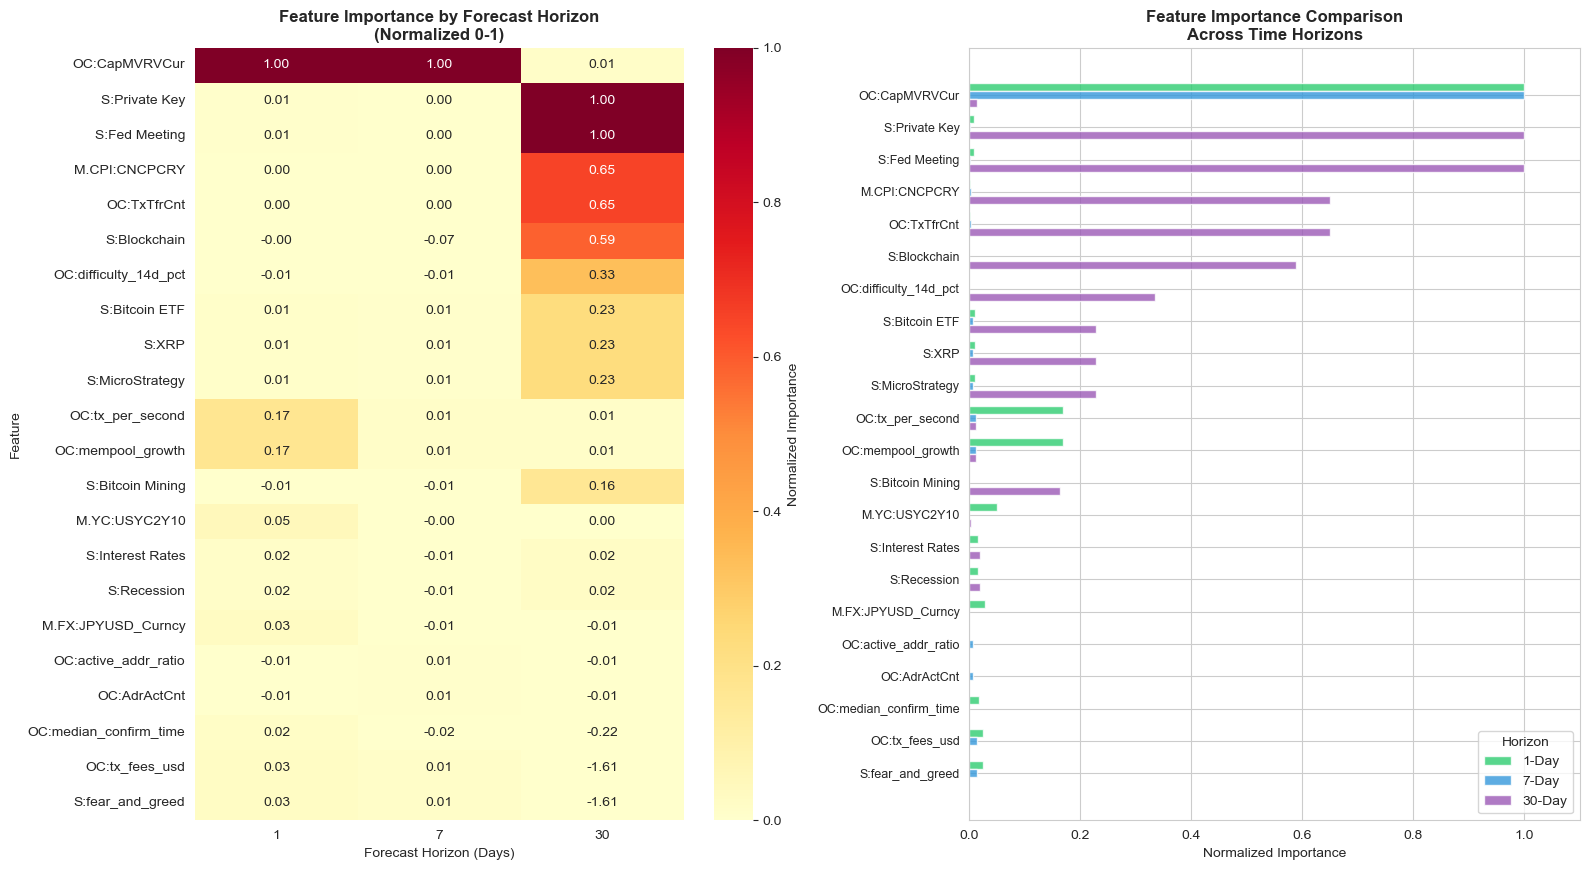


HORIZON ANALYSIS SUMMARY

📊 Top 3 Features by Horizon:

   1-Day Horizon:
    1. OC:CapMVRVCur: 1.000
    2. OC:mempool_growth: 0.168
    3. OC:tx_per_second: 0.168

   7-Day Horizon:
    1. OC:CapMVRVCur: 1.000
    2. S:fear_and_greed: 0.014
    3. OC:tx_fees_usd: 0.014

  30-Day Horizon:
    1. S:Private Key: 1.000
    2. S:Fed Meeting: 1.000
    3. OC:TxTfrCnt: 0.650

📈 Category Dominance by Horizon:
   1-Day: OnChain dominant ({'OnChain': 9, 'Sentiment': 7, 'Macro': 4})
   7-Day: OnChain dominant ({'OnChain': 10, 'Sentiment': 7, 'Macro': 3})
  30-Day: Sentiment dominant ({'OnChain': 7, 'Sentiment': 12, 'Macro': 1})

🔍 Key Observations:
  - Short-term (1d): Look for sentiment/volatility-driven features
  - Medium-term (7d): Mix of on-chain and macro factors expected
  - Long-term (30d): Macro/fundamentals should dominate


In [41]:
# Combine top features across all horizons into a comparison DataFrame
print("=" * 60)
print("FEATURE IMPORTANCE ACROSS HORIZONS")
print("=" * 60)

# Collect top N features from each horizon
top_n = 10
top_all = set()
for h in horizons:
    if h in results:
        top_all.update(results[h].head(top_n).index)

print(f"\nTotal unique top features across horizons: {len(top_all)}")

# Create heatmap data
heatmap_data = pd.DataFrame(index=sorted(top_all), columns=horizons, dtype=float)

for h in horizons:
    if h not in results:
        continue
    scores = results[h]
    
    for feat in top_all:
        if feat in scores.index:
            heatmap_data.loc[feat, h] = scores[feat]
        else:
            heatmap_data.loc[feat, h] = 0

# Sort by average importance across horizons
heatmap_data['avg'] = heatmap_data[horizons].mean(axis=1)
heatmap_data = heatmap_data.sort_values('avg', ascending=False)

# Create cleaner feature names for display
def clean_feature_name(name):
    """Shorten feature names for display."""
    name = name.replace('ONCHAIN_', 'OC:')
    name = name.replace('SENT_', 'S:')
    name = name.replace('MACRO_MKT_', 'M.MKT:')
    name = name.replace('MACRO_CPI_', 'M.CPI:')
    name = name.replace('MACRO_RATE_', 'M.RATE:')
    name = name.replace('MACRO_M2_', 'M.M2:')
    name = name.replace('MACRO_YC_', 'M.YC:')
    name = name.replace('MACRO_3M_', 'M.3M:')
    name = name.replace('MACRO_FX_', 'M.FX:')
    name = name.replace('_Index', '')
    return name

display_names = [clean_feature_name(f) for f in heatmap_data.index]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, max(8, len(top_all) * 0.4)))

# Heatmap (without avg column)
ax1 = axes[0]
plot_data = heatmap_data[horizons].copy()
plot_data.index = display_names

sns.heatmap(
    plot_data.astype(float), 
    annot=True, 
    fmt='.2f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Normalized Importance'},
    ax=ax1,
    vmin=0,
    vmax=1
)
ax1.set_title("Feature Importance by Forecast Horizon\n(Normalized 0-1)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Forecast Horizon (Days)")
ax1.set_ylabel("Feature")

# Bar chart comparison
ax2 = axes[1]
y_pos = np.arange(len(display_names))
width = 0.25
colors = ['#2ecc71', '#3498db', '#9b59b6']

for i, h in enumerate(horizons):
    if h in results:
        values = heatmap_data[h].values
        ax2.barh(y_pos + i*width, values, width, label=f'{h}-Day', color=colors[i], alpha=0.8)

ax2.set_yticks(y_pos + width)
ax2.set_yticklabels(display_names, fontsize=9)
ax2.set_xlabel("Normalized Importance")
ax2.set_title("Feature Importance Comparison\nAcross Time Horizons", fontsize=12, fontweight='bold')
ax2.legend(title='Horizon', loc='lower right')
ax2.set_xlim(0, 1.1)
ax2.invert_yaxis()

plt.tight_layout()

# Ensure output directory exists
(OUTPUT_DIR / 'images').mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_DIR / 'images' / 'horizon_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary analysis
print("\n" + "=" * 60)
print("HORIZON ANALYSIS SUMMARY")
print("=" * 60)

print("\n📊 Top 3 Features by Horizon:")
for h in horizons:
    if h in results:
        top3 = results[h].head(3)
        print(f"\n  {h:2d}-Day Horizon:")
        for i, (feat, score) in enumerate(top3.items(), 1):
            print(f"    {i}. {clean_feature_name(feat)}: {score:.3f}")

# Category dominance analysis
print("\n📈 Category Dominance by Horizon:")
for h in horizons:
    if h in results:
        top20 = results[h].head(20)
        cat_counts = {'OnChain': 0, 'Sentiment': 0, 'Macro': 0}
        for feat in top20.index:
            if feat.startswith('ONCHAIN'): cat_counts['OnChain'] += 1
            elif feat.startswith('SENT'): cat_counts['Sentiment'] += 1
            elif feat.startswith('MACRO'): cat_counts['Macro'] += 1
        
        dominant = max(cat_counts, key=cat_counts.get)
        print(f"  {h:2d}-Day: {dominant} dominant ({cat_counts})")

# Key insights
print("\n🔍 Key Observations:")
print("  - Short-term (1d): Look for sentiment/volatility-driven features")
print("  - Medium-term (7d): Mix of on-chain and macro factors expected")
print("  - Long-term (30d): Macro/fundamentals should dominate")

## 6. Export Results

Save key analysis outputs for reporting and further investigation.

In [42]:
# Ensure output directories exist
(OUTPUT_DIR / 'images').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'metrics').mkdir(parents=True, exist_ok=True)

# 1. Save feature importance results
importance_df = pd.DataFrame()
for h in horizons:
    if h in results:
        importance_df[f'{h}d_importance'] = results[h]
        importance_df[f'{h}d_rank'] = results[h].rank(ascending=False)

importance_df.to_csv(OUTPUT_DIR / 'metrics' / 'horizon_feature_importance.csv')
print(f"✓ Feature importance saved to: {OUTPUT_DIR / 'metrics' / 'horizon_feature_importance.csv'}")

# 2. Save transformation mapping
transform_df = pd.DataFrame.from_dict(diff_map, orient='index', columns=['Transformation'])
transform_df.to_csv(OUTPUT_DIR / 'metrics' / 'feature_transformations.csv')
print(f"✓ Transformation mapping saved to: {OUTPUT_DIR / 'metrics' / 'feature_transformations.csv'}")

# 3. Save regime analysis results
regime_results = {
    'horizon_days': h,
    'threshold': threshold,
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'regime_distribution': regime_counts.to_dict(),
    'accuracy': (preds == y_test).mean()
}
print(f"\n📊 Regime Classification Accuracy: {regime_results['accuracy']:.2%}")

# 4. Save the stationary dataset for further analysis
df_stat.to_csv(OUTPUT_DIR / 'processed_stationary_dataset.csv')
print(f"✓ Stationary dataset saved to: {OUTPUT_DIR / 'processed_stationary_dataset.csv'}")

print("\n" + "="*50)
print("ANALYSIS COMPLETE")
print("="*50)
print(f"\nKey findings saved to: {OUTPUT_DIR.resolve()}")

✓ Feature importance saved to: ../data/outputs/metrics/horizon_feature_importance.csv
✓ Transformation mapping saved to: ../data/outputs/metrics/feature_transformations.csv

📊 Regime Classification Accuracy: 21.00%
✓ Stationary dataset saved to: ../data/outputs/processed_stationary_dataset.csv

ANALYSIS COMPLETE

Key findings saved to: /Users/alvaro/Documents/GitHub/Projet-PI2-BTC/data/outputs
